(sec:openqm-qme-example)=
# An example: Single emitter

## Optical master equation for thermal radiation

Let us consider a hypothetical case where a single two-level emitters with the transition energy in a infrared range.  The emitter is placed in a hot photon gas of temperature around $1000$ k.

The system Hamiltonian is simply $H_{0} = \frac{\omega_{0}}{2} \sigma^{z}$ and the disippator is

$$
\mathcal{D}^{\uparrow}(\rho) = \gamma_{0} \bar{n}(\omega_{0}) \left(\sigma^{+}\rho\sigma^{-} - \frac{1}{2} \{\sigma^{-}\sigma^{+},\rho\}\right)
$$

and the other for emission

$$
\mathcal{D}^{\downarrow}(\rho) = \gamma_{0} [\bar{n}(\omega_{0})+1] \left(\sigma^{-}\rho\sigma^{+} - \frac{1}{2} \{\sigma^{+}\sigma^{-},\rho \} \right)
$$ 

The final form of the quantum master equation  is 

$$
\frac{d}{dt} \rho = -i \frac{\omega_{0}}{2} [\sigma^{z},\rho] + \mathcal{D}^{\uparrow} \rho  + \mathcal{D}^{\downarrow} \rho 
$$(eq:qme-optical)

which is simply an ordinary differential equation of $2\times2$ matrix.  This is simple enough to solve analytically.

## Bloch equations

There are many ways to solve Eq. {eq}`eq:qme-optical`.  There is a special method that works only for the two-dimensional Hilbert space.  Recalling that the identity matrix $I$ and the Pauli matrices $\sigma_{i}$ form a basis set. Expanding the density operator in the basis set,

$$
\rho(t) = \frac{1}{2}\left(I + \vec{r}(t) \cdot \vec{\sigma} \right)
$$

where $\vec{\sigma} = (\sigma^{x}, \sigma^{y}, \sigma^{z})$ and $\vec{r}(t) = (r_{1}(t),r_{2}(t),r_{3}(t))$ is the Bloch vector, which uniquely determine the density operator.{cite:p}`Breuer2002,Lambropoulos2007`  Since the density operator is self-adjoint, $\vec{r}$ is real.  In fact, it is easy to show that $\vec{r} = \langle \vec{\sigma}\rangle = \text{tr}\left[\vec{\sigma}\rho(t)\right]$.  Multiply $\vec{\sigma}$ to Eq. {eq}`eq:qme-optical` and taking trace, we obtain the equation of motion for the Bloch vector is given by

$$
\begin{aligned}
\frac{d}{dt} \langle \sigma^{x}(t)\rangle &= \omega_0 \langle \sigma^{y} (t)\rangle - \frac{\gamma}{2} \langle \sigma^{x}(t)\rangle \\
\frac{d}{dt} \langle \sigma^{y}(t)\rangle &= \omega_0 \langle \sigma^{x} (t)\rangle - \frac{\gamma}{2} \langle \sigma^{y}(t)\rangle \\
\frac{d}{dt} \langle \sigma^{z}(t)\rangle &= - \gamma \langle \sigma^{x} (t)\rangle  - \gamma_{0}
\end{aligned}
$$(eq:Bloch-eq)

where $\gamma = \gamma_0 (2\bar{n}+1)$.  Equation {eq}`eq:Bloch-eq` is called the Bloch equation.{cite:p}`Breuer2002,Meystre2007`

By letting the left hand side 0, we can immediately find the steady state.

$$
\langle \sigma^{x}\rangle_{ss} = \langle \sigma^{y}\rangle_{ss} = 0, \qquad \langle \sigma^{z}\rangle_{ss} = -\frac{\gamma_0}{\gamma} = -\frac{1}{2\bar{n}+1}
$$

The probability to find the atom in the excited state is given by

$$
p_{e}^{ss} = \frac{1}{2} \left(1 + \langle \sigma^{z}\rangle_{ss}\right) = \frac{\bar{n}}{2\bar{n}+1} = \frac{1}{Z_R}e^{-\beta \omega_0}
$$(eq:p_e_ss)

which is just the thermal equilibrium state.  Hence, the system is relaxed to the thermal state.  


Next, we calculate the relaxation to the thermal state starting from a pure state $|\psi_0\rangle = \cos \theta |0\rangle + \sin \theta |1\rangle$, which gives the initial density operator

$$
\rho(0) = |\psi_0\rangle\langle \psi_0| = \cos^2\theta |0\rangle\langle 0| + \cos\theta\sin\theta |0\rangle\langle 1| + \cos\theta\sin\theta |1\rangle\langle 0| +  \sin^2\theta |1\rangle\langle 1| 
$$

The initial condition for the Bloch equation is 

$$
\langle \sigma^{x}(0) \rangle =\sin (2\theta), \quad \langle \sigma^{y}(0) \rangle = 0, \quad \langle \sigma^{z}(0) \rangle = -\cos(2\theta)
$$

The solution is 

$$
\begin{eqnarray}
\langle \sigma^{x}(t) \rangle &=& e^{-\gamma t/2} \cos(\omega_{0} t) \sin(2\theta) \\
\langle \sigma^{y}(t) \rangle &=& e^{-\gamma t/2} \sin(\omega_{0} t) \sin(2\theta) \\
\langle \sigma^{z}(t) \rangle &=& -e^{-\gamma t}  \cos(2\theta)  + (1- e^{-\gamma t}) \langle \sigma^{z} \rangle_{ss}
\end{eqnarray}
$$(eq:qme-Bloch-solution)

which indicates $\gamma$ is the relaxation rate.

Equation {eq}`eq:qme-Bloch-solution` that this process involves the dissipative type of decoherence with $T_1 = 1/\gamma$ and $T_2 = 2/\gamma$.  Thus $T_2= 2 T_1$ as mentioned in {numref}`ch:coherence`.

## Solving a master equation numerically using QuTiP

As introduced in {numref}`ch:qutip`, `QuTiP` has a module `mesolve()` which solve quantum master equations.    FOr numerical method, we first need to set up parameters.  As discussed in {numref}`sec:openqm-qme-scaling`, we use dimensionless units. First of all, we always set $\omega_{0}=1$.  Then, temperature is about $T=0.86\omega_{0}$.  We use a typical spontaneous emission rate $\gamma_{0} = 10^{-8} \omega_{0}$.    You can see from the analytical solution {eq}`eq:qme-Bloch-solution`, the state oscillates rapidly and decays slowly. With this these parameter values, we cannot integrate the master equation  numerically. We need to use the rotating frame discussed in {numref}`sec:openqm-qme-rotating-frame`.  In the interaction picture, the Hamiltonian is eliminated and the master equation is simply

$$
\frac{d}{dt} \tilde{\rho} = \mathcal{D}^{\uparrow}(\tilde{\rho}) +  \mathcal{D}^{\downarrow}(\tilde{\rho}).
$$

The following code solve the same master equation as the above and plots the Bloch vectors.  The theoretical results are also plotted with dashed lines.  Since the numerical results agree with the analytical solution perfectly, the theoretical plots are invisible. We also plot the evolution of Bloch vector in the Bloch sphere. The state is initially on the surface of the Bloch sphere since it is a pure state. Then, the state spirals down to the thermal equilibrium located on the 
$z$ axis.

The result shows that $\tilde{\rho}$ approaches to the thermal state as expected.

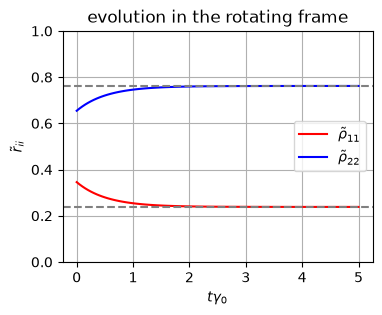

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# Parameters
omega0 = 1.0   # excitation energy
gamma0 = 1.e-08   # spontaneous emission rate
T = 0.86  # tempeature of photon gas
nbar = 1/(np.exp(omega0/T)-1) # Planck distribution
theta = 2*np.pi/10 # initial condition

# decay rates normalized by gamma0
gamma1 = nbar   # coefficient to absorption
gamma2 = nbar+1  # coefficient to emission
gamma = gamma1+gamma2

# empty Hamiltonian (in the rotating frame)
H = 0*qeye(2) 

# Jump operators
c_ops = [np.sqrt(gamma1) * sigmap(),np.sqrt(gamma2) * sigmam()]

# Initial state: start in the ground state |g>
psi0 = basis(2,0)*np.sin(theta) + basis(2,1)*np.cos(theta)

# evaluation time
times = np.linspace(0, 5, 100)

# observables to compute
observables = [sigmax(),sigmay(),sigmaz()]

# solve the Lindblad Equation
result = mesolve(H, psi0, times, c_ops, e_ops=[])

rho = result.states

#--Gibbs
q = [np.exp(-omega0/(2*T)),np.exp(omega0/(2*T))]
Z = sum(q)
q = q/Z
p1=[]
p2=[]

for k in range(times.size):
    x=rho[k]
    p1.append(x[0,0].real)
    p2.append(x[1,1].real)

# 4. Plotting the Time Evolution
plt.figure(figsize=(4, 3))
plt.plot(times,p1,label=r"$\tilde{\rho}_{11}$",color="r")
plt.plot(times,p2,label=r"$\tilde{\rho}_{22}$",color="b")
plt.axhline(y=q[0],ls='--',color="grey")
plt.axhline(y=q[1],ls='--',color="grey")
plt.title("evolution in the rotating frame")
plt.xlabel(r"$t \gamma_{0}$")
plt.ylabel(r"$\tilde{r}_{ii}$")
plt.ylim([0,1])
plt.legend(loc=5)
plt.grid(True)
plt.show()

## Expectation values

It the rotating frame, the oscillation is frozen at $t=0$.  Thus $\langle\tilde{\sigma}^{x}\rangle  = e^{-\gamma t/2} \sin(2\theta)$ and $\langle \tilde{\sigma}^{y} \rangle = 0$.  Since $\sigma^{z}$ commutes with $U$, $\langle\tilde{\sigma}^{z}\rangle = \langle\sigma^{z}\rangle$. 

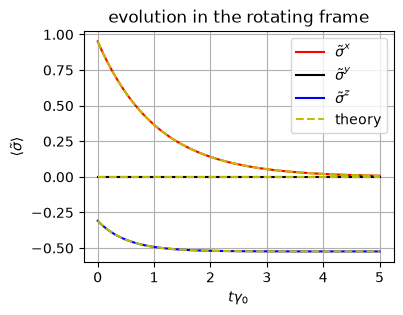

In [2]:

observables = [sigmax(),sigmay(),sigmaz()]

# solve the Lindblad Equation
result = mesolve(H, psi0, times, c_ops, e_ops=observables)

sx = result.expect[0]
sy = result.expect[1]
sz = result.expect[2]

gamma = 2*nbar+1
sz_ss = -1/gamma
sx_th = np.exp(-gamma/2*times)*np.sin(2*theta)
sy_th = 0*times
sz_th = sz_ss - np.exp(-gamma*times)*(np.cos(2*theta)+sz_ss)
# 4. Plotting the Time Evolution
plt.figure(figsize=(4, 3))
plt.plot(times,sx,label=r"$\tilde{\sigma}^{x}$",color="r")
plt.plot(times,sy,label=r"$\tilde{\sigma}^{y}$",color="k")
plt.plot(times,sz,label=r"$\tilde{\sigma}^{z}$",color="b")
plt.plot(times,sx_th,label=r"theory",color="y",ls='--')
plt.plot(times,sy_th,color="y",ls='--')
plt.plot(times,sz_th,color="y",ls='--')
plt.title("evolution in the rotating frame")
plt.xlabel(r"$t \gamma_{0}$")
plt.ylabel(r"$\langle\tilde{\sigma}\rangle$")

plt.legend(loc=1)
plt.grid(True)
plt.show()

## Coherence functions

The coherence functions measures the spatio-temporal correlation of radiation fields. (See {numref}`sec:coherence-g1` and {numref}`sec:coherence-g2`.)  To compute them, we need the creation and annihilation operators.  The open quantum approach does not solve the evolution of the radiation field.   Then, how do we calculate them?  As introduced in {numref}`sec:radiation-field`, the radiation field generated by the emitters can be expressed with the operators of the emitters.  Using Eq. {eq}`eq:source_field_approx`, the coherence functions for a single emitter which is placed at the origin of coordinates are given by

$$
g^{(1)}(\tau) = \frac{\langle \sigma^{+}(\tau) \sigma^{-}(0)\rangle_{ss}}{\langle  \sigma^{+}(0)\sigma^{-}(0) \rangle_{ss}} =  \frac{\text{tr}\left[\sigma^{-} e^{\mathcal{L} \tau} \left(\rho_{ss} \sigma^{+}\right)\right]}{\text{tr}\left[\sigma^{+}\sigma^{-} \rho_{ss}\right]} = \langle e|(e^{\mathcal{L} \tau} |e\rangle\langle e|) |e \rangle = p_{e}(\tau;e) = e^{-\gamma_{0}\tau}
$$(eq:g1-emission)

where $\mathcal{L} = \mathcal{D}^{\uparrow} +  \mathcal{D}^{\downarrow}$ and $p_{e}(\tau;e)$ is a conditional probability that the system is in the excited state $|e\rangle$ at $t=0$ and remains in the excited state after $\tau$.  For a single emitter, the excited state decays with decay rate $\gamma_{0}$ and thus $g^{(1)}(\tau) = e^{-\gamma_{0} t}$.  The numerical result agree with it perfectly.



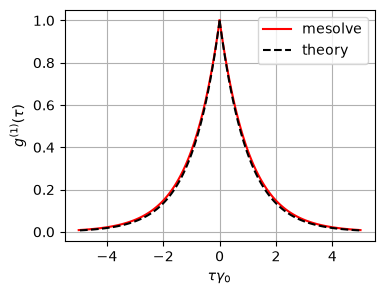

In [3]:
# Continued from the previous code block. 
# You need to execute it before running this code.

# We already set up Hamiltonian H, collapse operators c_ops
# in the first code block in this page.
# We need to modify
# 1) psi0 - initial state
# 2) operator to be measured. that is sigmaz

rho_ss = steadystate(H,c_ops)

# intensity
I = expect(sigmap()*sigmam(),rho_ss)

rho0 = rho_ss*sigmap()

result = mesolve(H,rho0,times,c_ops,e_ops=sigmam())

g1 = result.expect[0]/I
g1_th = np.exp(-times)

plt.figure(figsize=(4,3))
plt.plot( times, g1.real, c='r',label="mesolve")
plt.plot(-times, g1.real, c='r')
plt.plot( times, g1_th, c='k',ls='--',label="theory")
plt.plot(-times, g1_th, c='k',ls='--')
plt.xlabel(r'$\tau\gamma_{0}$')
plt.ylabel(r'$g^{(1)}(\tau)$')
plt.legend(loc=1)
plt.grid(True)
plt.show()

## Second-order coherence function

$$
g^{(2)}(\tau) = \frac{\langle \sigma^{+}(0)\sigma^{+}(\tau)\sigma^{-}(\tau) \sigma^{-}(0) \rangle_{ss}}{(\langle  \sigma^{+}(0)\sigma^{+}(0) \rangle_{ss})^2}
=\frac{\text{tr}\left[\sigma^{+}\sigma^{-} e^{\mathcal{L}\tau} \left(\sigma^{-}\rho_{ss}\sigma^{+}\right)\right]}{\left(\text{tr}\left[\sigma^{+}\sigma^{-}\rho_{ss}\right]\right)^2}
$$(eq:g2-emission)

Using Eqs. {eq}`eq:sigma-pm`, $e^{\mathcal{L}t} (\sigma^{-}\rho_{ss}\sigma^{+}) = \langle e|\rho| e\rangle e^{\mathcal{L}t}(|g\rangle\langle g|)$ , we find an explicit expression of the correlation function

$$
g^{(2)}(\tau)= \frac{\langle e | \left(e^{\mathcal{L}\tau} |g\rangle\langle g |\right) | e \rangle}{\langle e | \rho^{ss} | e \rangle}  = \frac{\langle e | \rho(\tau;g) | e \rangle}{\langle e | \rho^{ss} | e \rangle} = \frac{p_{e}(\tau;g)}{p_{e}^{ss}}
$$(eq:g2_explicit)

where $\rho(\tau;g)$ is a state at $t=\tau$ starting from the ground state at $t=0$ and $p_{e}(\tau;g)$ is a conditional probability that the system is in the ground state at $t=0$ and in the excited state at $t=\tau$.  $p_{s}^{ss}$ is the probability of the steady state being in $|e\rangle$ which we already know from {eq}`eq:p_e_ss`.  Noting that $\lim_{\tau \rightarrow \infty} p_{e}(\tau;g) = p_{e}^{ss}$, we find $\lim_{\tau \rightarrow \infty} g^{(2)}(\tau) = 1$.  On the other hand, $\lim_{\tau \rightarrow 0} p_{e}(\tau;g) = 0$ since $|e\rangle$ and $|g\rangle$ are orthogonal.  Thus we have $g^{(2)}(0) = 0$.

From the final expression of Eq. {eq}`eq:g2_explicit`, only we need is $p_{e}(\tau;g)$ which can be obtained by solving the master equation. Using the general solution {eq}`eq:qme-Bloch-solution` with initial condition $\theta=0$, we find $p_{e}(\tau;g) = \frac{1}{2}\left(1-e^{-\gamma \tau}\right)\left(1+\langle\sigma_z^{ss}\right)$ and $p_{e}^{ss} = \frac{1}{2}\left(1+\langle\sigma_z^{ss}\right)$, from which we obtain an explicit expression of the second-order coherence:

$$
g^{(2)}(\tau) =  1-e^{-\gamma |\tau|}
$$

which shows perfect antibunching.

The following code calculates it numerically using `mesolver` in `QuTip`, which agrees with the analytical result. 


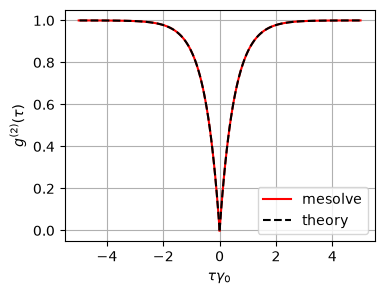

In [4]:
rho0 = sigmam()*rho_ss*sigmap()

result = mesolve(H,rho0,times,c_ops,e_ops=sigmap()*sigmam())

g2 = result.expect[0]/I**2
g2_th = 1 - np.exp(-gamma*times)
plt.figure(figsize=(4,3))
plt.plot( times, g2.real, c='r',label="mesolve")
plt.plot(-times, g2.real, c='r')
plt.plot( times, g2_th, c='k', ls='--',label="theory")
plt.plot(-times, g2_th, c='k', ls='--')
plt.xlabel(r'$\tau\gamma_{0}$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.legend(loc=4)
plt.grid(True)
plt.show()